# 🛍️ Black Friday Sales Prediction

Predicting customer purchase amounts using demographic and product data.

## 1. Problem Statement

A retail company wants to understand customer purchase behaviour (specifically, **purchase amount**) against various products of different categories.

They have shared purchase summary of various customers for selected high-volume products from last month. The task is to **build a model to predict the purchase amount** of customers against various products, which will help the company to create a personalised offer for customers against different products.

## 2. Dataset Description

| Column | Description |
|--------|-------------|
| User_ID | Unique User ID |
| Product_ID | Unique Product ID |
| Gender | Sex of User (M/F) |
| Age | Age in bins |
| Occupation | Occupation (masked) |
| City_Category | Category of City (A, B, C) |
| Stay_In_Current_City_Years | No. of years in current city |
| Marital_Status | Marital Status (0/1) |
| Product_Category_1/2/3 | Product category (masked) |
| **Purchase** | **Target — Purchase Amount ($)** |

## 3. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from math import sqrt

sns.set_theme(style="whitegrid")
print("All libraries imported successfully ✅")

All libraries imported successfully ✅


## 4. Loading Data

In [2]:
df = pd.read_csv("Data/BlackFridaySales.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (550068, 12)


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [3]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  str    
 2   Gender                      550068 non-null  str    
 3   Age                         550068 non-null  str    
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  str    
 6   Stay_In_Current_City_Years  550068 non-null  str    
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 50.4 MB


In [4]:
# Statistical summary
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


## 5. Checking Missing Values

In [5]:
# Missing value count and percentage
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing['Missing Count'] > 0]

,Missing Count,Missing %
Product_Category_2,173638,31.57
Product_Category_3,383247,69.67


> **Note:** `Product_Category_2` has ~31% and `Product_Category_3` has ~69% missing values. We will fill them with `0` (indicating no sub-category).

## 6. Exploratory Data Analysis (EDA)

### 6.1 Target Variable — Purchase

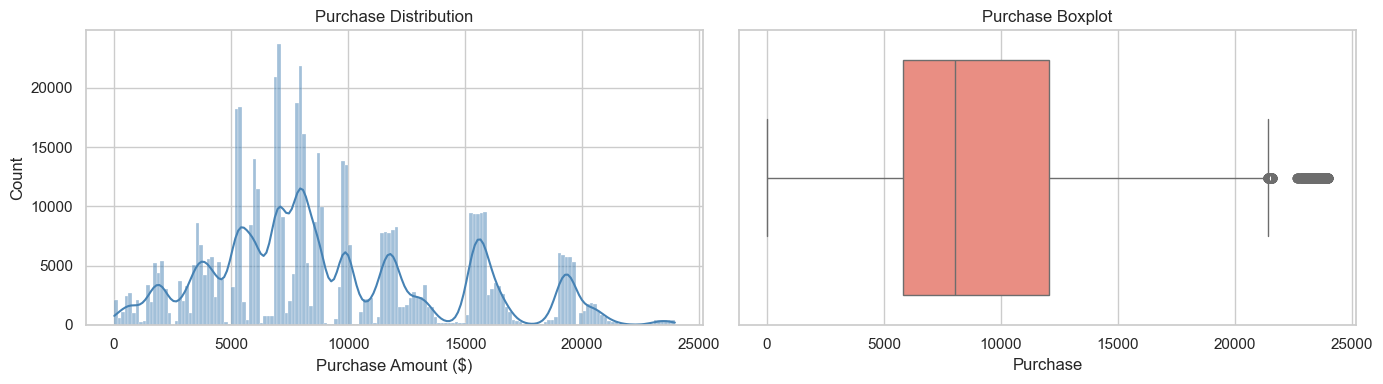

Skewness : 0.600
Kurtosis : -0.338
Mean     : $9,264
Std Dev  : $5,023
Range    : $12 – $23961


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
sns.histplot(df['Purchase'], kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Purchase Distribution')
axes[0].set_xlabel('Purchase Amount ($)')

# Boxplot
sns.boxplot(x=df['Purchase'], color='salmon', ax=axes[1])
axes[1].set_title('Purchase Boxplot')

plt.tight_layout()
plt.show()

print(f"Skewness : {df['Purchase'].skew():.3f}")
print(f"Kurtosis : {df['Purchase'].kurtosis():.3f}")
print(f"Mean     : ${df['Purchase'].mean():,.0f}")
print(f"Std Dev  : ${df['Purchase'].std():,.0f}")
print(f"Range    : ${df['Purchase'].min()} – ${df['Purchase'].max()}")

### 6.2 Gender

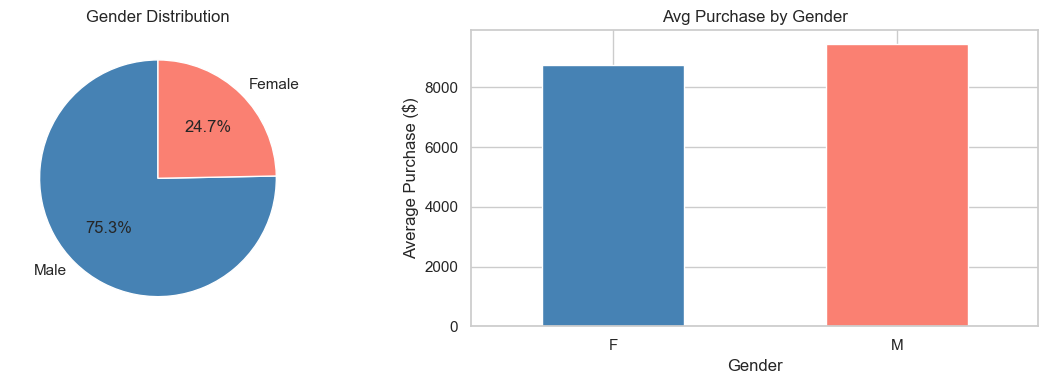

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts, labels=['Male','Female'], autopct='%1.1f%%',
            colors=['steelblue','salmon'], startangle=90)
axes[0].set_title('Gender Distribution')

# Avg purchase
df.groupby('Gender')['Purchase'].mean().plot(kind='bar', color=['steelblue','salmon'],
                                              ax=axes[1], rot=0)
axes[1].set_title('Avg Purchase by Gender')
axes[1].set_ylabel('Average Purchase ($)')

plt.tight_layout()
plt.show()

### 6.3 Age Group

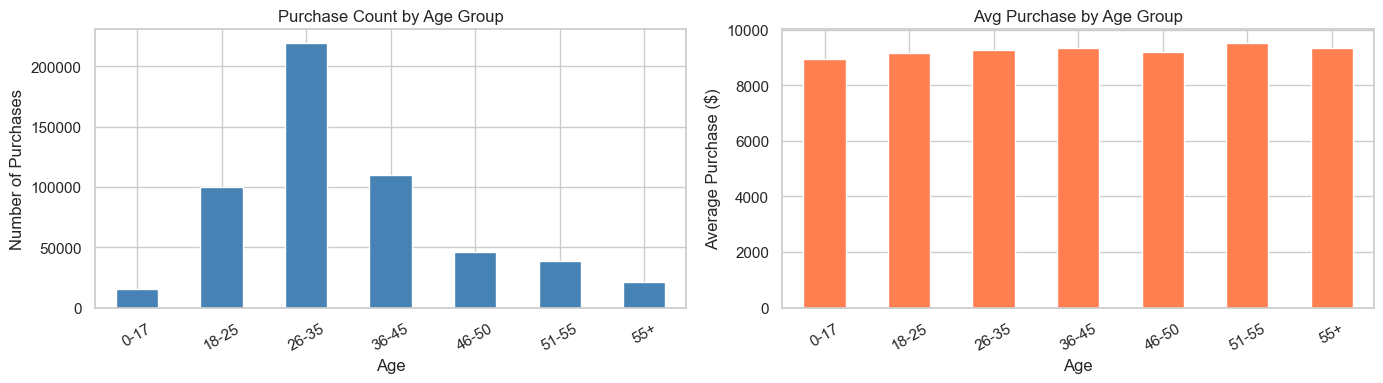

In [8]:
age_order = ['0-17','18-25','26-35','36-45','46-50','51-55','55+']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['Age'].value_counts().reindex(age_order).plot(kind='bar', color='steelblue',
                                                   ax=axes[0], rot=30)
axes[0].set_title('Purchase Count by Age Group')
axes[0].set_ylabel('Number of Purchases')

df.groupby('Age')['Purchase'].mean().reindex(age_order).plot(kind='bar',
                                                              color='coral',
                                                              ax=axes[1], rot=30)
axes[1].set_title('Avg Purchase by Age Group')
axes[1].set_ylabel('Average Purchase ($)')

plt.tight_layout()
plt.show()

### 6.4 City Category

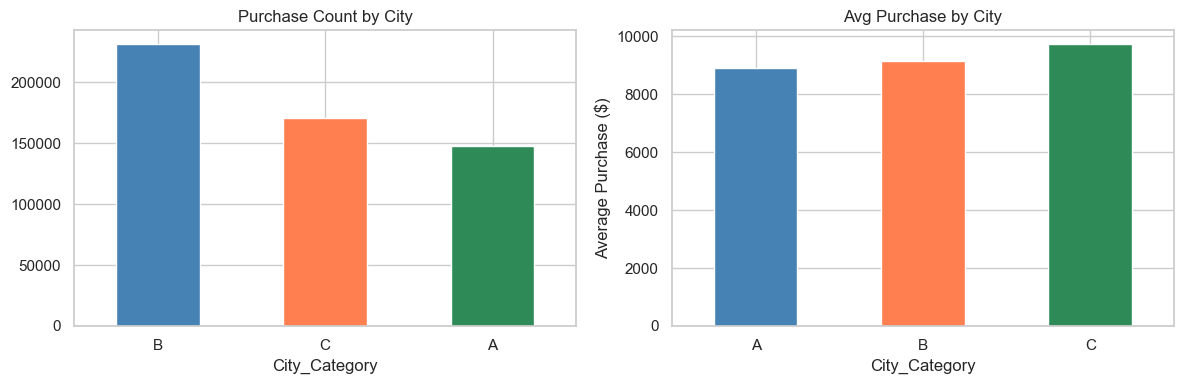

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['City_Category'].value_counts().plot(kind='bar', color=['steelblue','coral','seagreen'],
                                         ax=axes[0], rot=0)
axes[0].set_title('Purchase Count by City')

df.groupby('City_Category')['Purchase'].mean().plot(kind='bar',
                                                     color=['steelblue','coral','seagreen'],
                                                     ax=axes[1], rot=0)
axes[1].set_title('Avg Purchase by City')
axes[1].set_ylabel('Average Purchase ($)')

plt.tight_layout()
plt.show()

### 6.5 Stay in Current City (Years)

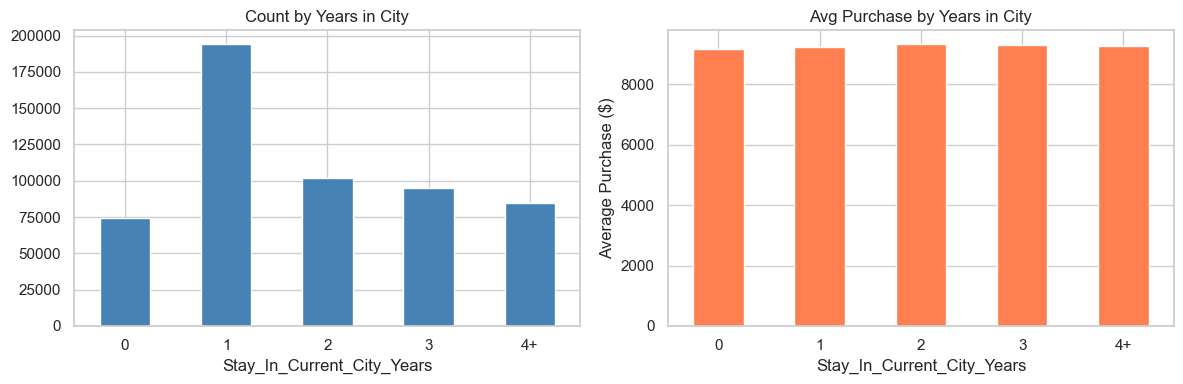

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Stay_In_Current_City_Years'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', ax=axes[0], rot=0)
axes[0].set_title('Count by Years in City')

df.groupby('Stay_In_Current_City_Years')['Purchase'].mean().plot(
    kind='bar', color='coral', ax=axes[1], rot=0)
axes[1].set_title('Avg Purchase by Years in City')
axes[1].set_ylabel('Average Purchase ($)')

plt.tight_layout()
plt.show()

### 6.6 Marital Status

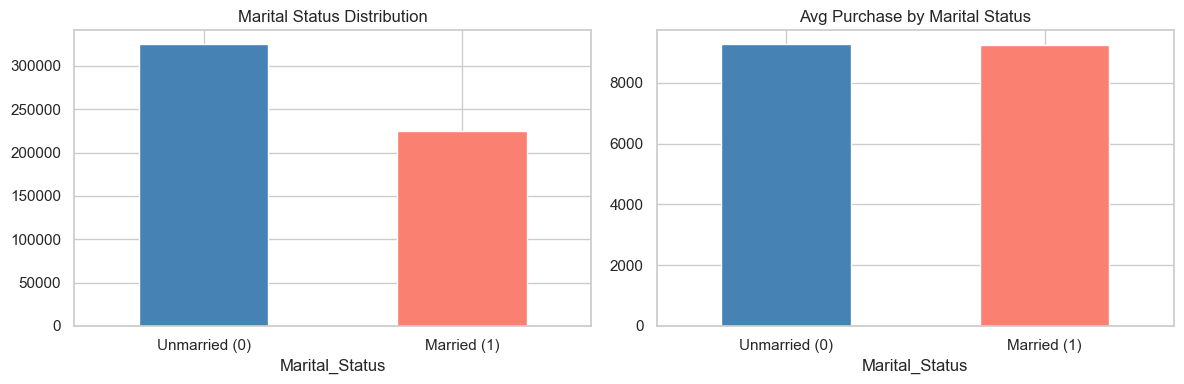

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Marital_Status'].value_counts().plot(kind='bar', color=['steelblue','salmon'],
                                          ax=axes[0], rot=0)
axes[0].set_xticklabels(['Unmarried (0)', 'Married (1)'])
axes[0].set_title('Marital Status Distribution')

df.groupby('Marital_Status')['Purchase'].mean().plot(kind='bar',
                                                      color=['steelblue','salmon'],
                                                      ax=axes[1], rot=0)
axes[1].set_xticklabels(['Unmarried (0)', 'Married (1)'])
axes[1].set_title('Avg Purchase by Marital Status')

plt.tight_layout()
plt.show()

### 6.7 Product Categories

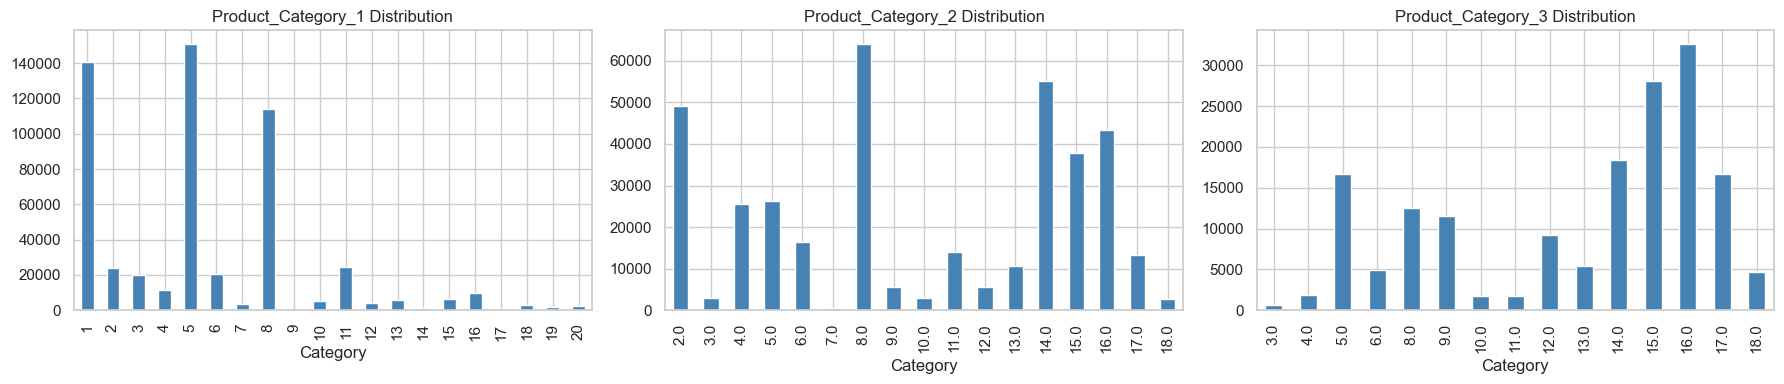

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(['Product_Category_1','Product_Category_2','Product_Category_3']):
    df[col].value_counts().sort_index().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Category')
plt.tight_layout()
plt.show()

### 6.8 Correlation Heatmap

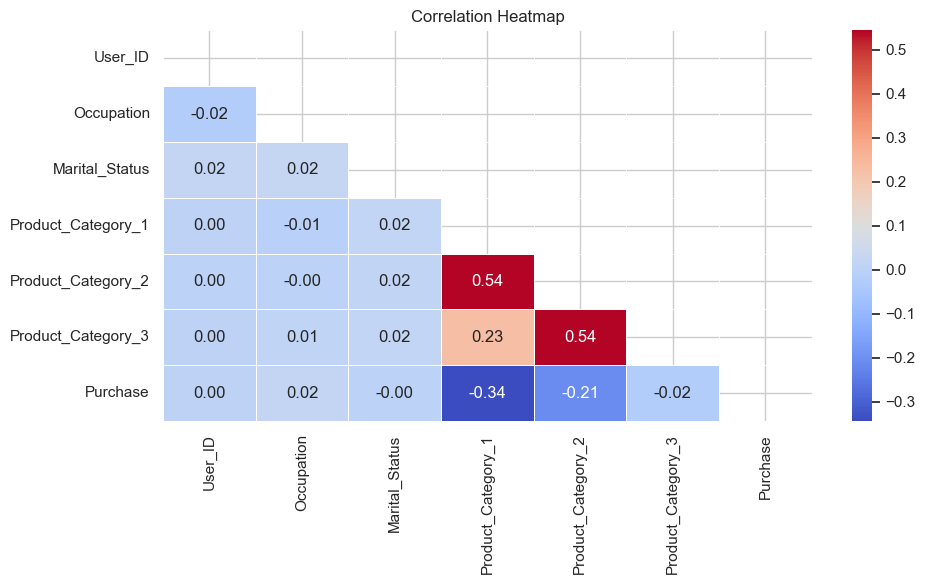

In [13]:
plt.figure(figsize=(10, 6))
# Fix: numeric_only=True required in newer pandas versions
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 6.9 Cross-Feature Analysis

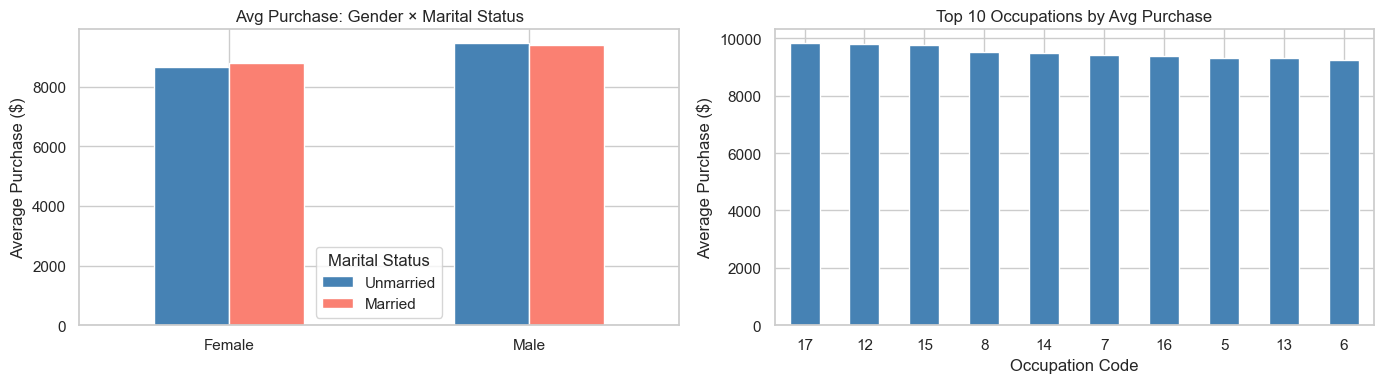

Observation: Single males spend the most. Occupation code drives significant variation.


In [14]:
# ── 6.9a Gender × Marital Status — who spends the most? ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cross = df.groupby(['Gender', 'Marital_Status'])['Purchase'].mean().unstack()
cross.columns = ['Unmarried', 'Married']
cross.index = ['Female', 'Male']
cross.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], rot=0)
axes[0].set_title('Avg Purchase: Gender × Marital Status')
axes[0].set_ylabel('Average Purchase ($)')
axes[0].legend(title='Marital Status')

# ── 6.9b Top 10 Occupations by avg purchase ──────────────────────────────────
occ = df.groupby('Occupation')['Purchase'].mean().sort_values(ascending=False).head(10)
occ.plot(kind='bar', ax=axes[1], color='steelblue', rot=0)
axes[1].set_title('Top 10 Occupations by Avg Purchase')
axes[1].set_xlabel('Occupation Code')
axes[1].set_ylabel('Average Purchase ($)')

plt.tight_layout()
plt.show()

print("Observation: Single males spend the most. Occupation code drives significant variation.")

## 7. Data Preprocessing

In [15]:
data = df.copy()

# ── Step 1: Fill missing values ──────────────────────────────────────────────
# Product_Category_2 and 3 filled with 0 (no sub-category)
data['Product_Category_2'] = data['Product_Category_2'].fillna(0).astype('int64')
data['Product_Category_3'] = data['Product_Category_3'].fillna(0).astype('int64')
print("✅ Missing values filled")

# ── Step 2: Encode Gender (binary) ──────────────────────────────────────────
data['Gender'] = data['Gender'].map({'M': 1, 'F': 0})
print("✅ Gender encoded: M=1, F=0")

# ── Step 3: Encode Age with correct ordinal order ───────────────────────────
# Fix: LabelEncoder assigns alphabetical order, NOT numeric age order.
# Manually map to preserve correct age ordering.
age_map = {'0-17': 0, '18-25': 1, '26-35': 2, '36-45': 3, '46-50': 4, '51-55': 5, '55+': 6}
data['Age'] = data['Age'].map(age_map)
print("✅ Age encoded with correct ordinal mapping:", age_map)

# ── Step 4: Encode City_Category ────────────────────────────────────────────
data['City_Category'] = data['City_Category'].map({'A': 0, 'B': 1, 'C': 2})
print("✅ City_Category encoded: A=0, B=1, C=2")

# ── Step 5: One-hot encode Stay_In_Current_City_Years ───────────────────────
data = pd.get_dummies(data, columns=['Stay_In_Current_City_Years'], prefix='Stay')
print("✅ Stay_In_Current_City_Years one-hot encoded")

# ── Step 6: Drop ID columns (not useful for prediction) ─────────────────────
data = data.drop(['User_ID', 'Product_ID'], axis=1)
print("✅ Dropped User_ID and Product_ID")

print(f"\nFinal dataset shape: {data.shape}")
data.head()

✅ Missing values filled
✅ Gender encoded: M=1, F=0
✅ Age encoded with correct ordinal mapping: {'0-17': 0, '18-25': 1, '26-35': 2, '36-45': 3, '46-50': 4, '51-55': 5, '55+': 6}
✅ City_Category encoded: A=0, B=1, C=2
✅ Stay_In_Current_City_Years one-hot encoded
✅ Dropped User_ID and Product_ID

Final dataset shape: (550068, 14)


,Gender,Age,Occupation,City_Category,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Stay_0,Stay_1,Stay_2,Stay_3,Stay_4+
0,0,0,10,0,0,3,0,0,8370,False,False,True,False,False
1,0,0,10,0,0,1,6,14,15200,False,False,True,False,False
2,0,0,10,0,0,12,0,0,1422,False,False,True,False,False
3,0,0,10,0,0,12,14,0,1057,False,False,True,False,False
4,1,6,16,2,0,8,0,0,7969,False,False,False,False,True


In [16]:
# Confirm no missing values remain
print("Missing values after preprocessing:")
print(data.isnull().sum())

Missing values after preprocessing:
Gender                0
Age                   0
Occupation            0
City_Category         0
Marital_Status        0
Product_Category_1    0
Product_Category_2    0
Product_Category_3    0
Purchase              0
Stay_0                0
Stay_1                0
Stay_2                0
Stay_3                0
Stay_4+               0
dtype: int64


### 7.1 Outlier Analysis — Purchase Column

Q1          : $5,823
Q3          : $12,054
IQR         : $6,231
Lower bound : $-3,524
Upper bound : $21,400
Outliers    : 2,677 rows (0.49%)


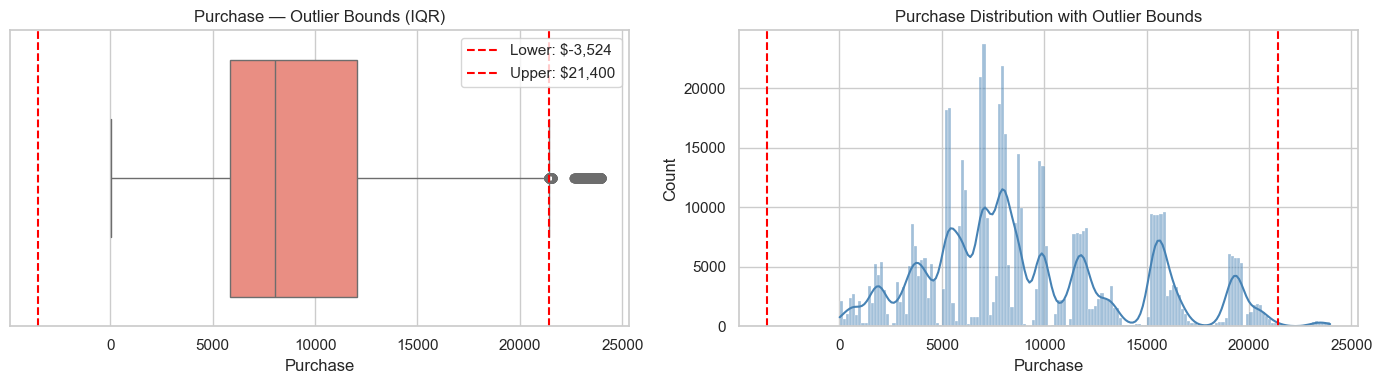


Note: Outliers are kept — they represent genuine high-value purchases, not data errors.


In [17]:
# ── Outlier detection using IQR method ───────────────────────────────────────
Q1 = data['Purchase'].quantile(0.25)
Q3 = data['Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['Purchase'] < lower) | (data['Purchase'] > upper)]
print(f"Q1          : ${Q1:,.0f}")
print(f"Q3          : ${Q3:,.0f}")
print(f"IQR         : ${IQR:,.0f}")
print(f"Lower bound : ${lower:,.0f}")
print(f"Upper bound : ${upper:,.0f}")
print(f"Outliers    : {len(outliers):,} rows ({len(outliers)/len(data)*100:.2f}%)")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=data['Purchase'], color='salmon', ax=axes[0])
axes[0].axvline(lower, color='red', linestyle='--', label=f'Lower: ${lower:,.0f}')
axes[0].axvline(upper, color='red', linestyle='--', label=f'Upper: ${upper:,.0f}')
axes[0].set_title('Purchase — Outlier Bounds (IQR)')
axes[0].legend()

sns.histplot(data['Purchase'], kde=True, color='steelblue', ax=axes[1])
axes[1].axvline(lower, color='red', linestyle='--')
axes[1].axvline(upper, color='red', linestyle='--')
axes[1].set_title('Purchase Distribution with Outlier Bounds')

plt.tight_layout()
plt.show()

print("\nNote: Outliers are kept — they represent genuine high-value purchases, not data errors.")

## 8. Train / Test Split

In [18]:
X = data.drop('Purchase', axis=1)
y = data['Purchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"Features       : {X.columns.tolist()}")

Training set   : 440,054 rows
Test set       : 110,014 rows
Features       : ['Gender', 'Age', 'Occupation', 'City_Category', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Stay_0', 'Stay_1', 'Stay_2', 'Stay_3', 'Stay_4+']


## 9. Modeling

### Helper — Evaluation Function

In [19]:
import time
from sklearn.model_selection import cross_val_score

results = {}

def evaluate(name, model, y_true, y_pred, X_train, y_train):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    # 5-fold cross-validation on training set (scoring = neg RMSE)
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=5, scoring='neg_root_mean_squared_error',
                                n_jobs=-1)
    cv_rmse_mean = -cv_scores.mean()
    cv_rmse_std  = cv_scores.std()

    results[name] = {
        'MAE'         : mae,
        'RMSE'        : rmse,
        'R2'          : r2,
        'CV_RMSE_mean': cv_rmse_mean,
        'CV_RMSE_std' : cv_rmse_std
    }

    print(f"{'─'*45}")
    print(f"  Model        : {name}")
    print(f"  MAE          : {mae:,.2f}")
    print(f"  RMSE         : {rmse:,.2f}")
    print(f"  R²           : {r2:.4f}")
    print(f"  CV RMSE      : {cv_rmse_mean:,.2f} ± {cv_rmse_std:,.2f}")
    print(f"{'─'*45}")

### 9.1 Linear Regression

In [20]:
start = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print(f"Training time: {time.time()-start:.2f}s")
evaluate("Linear Regression", lr_model, y_test, lr_pred, X_train, y_train)

Training time: 0.22s
─────────────────────────────────────────────
  Model        : Linear Regression
  MAE          : 3,526.58
  RMSE         : 4,618.67
  R²           : 0.1510
  CV RMSE      : 4,626.74 ± 10.64
─────────────────────────────────────────────


### 9.2 Decision Tree Regressor

In [21]:
start = time.time()
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print(f"Training time: {time.time()-start:.2f}s")
evaluate("Decision Tree", dt_model, y_test, dt_pred, X_train, y_train)

Training time: 2.55s
─────────────────────────────────────────────
  Model        : Decision Tree
  MAE          : 2,367.86
  RMSE         : 3,350.93
  R²           : 0.5531
  CV RMSE      : 3,378.83 ± 10.33
─────────────────────────────────────────────


### 9.3 Random Forest Regressor

In [22]:
start = time.time()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print(f"Training time: {time.time()-start:.2f}s")
evaluate("Random Forest", rf_model, y_test, rf_pred, X_train, y_train)

Training time: 25.89s
─────────────────────────────────────────────
  Model        : Random Forest
  MAE          : 2,225.02
  RMSE         : 3,059.46
  R²           : 0.6275
  CV RMSE      : 3,054.27 ± 9.52
─────────────────────────────────────────────


### 9.4 XGBoost Regressor

In [23]:
start = time.time()
xgb_model = XGBRegressor(
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=40,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print(f"Training time: {time.time()-start:.2f}s")
evaluate("XGBoost", xgb_model, y_test, xgb_pred, X_train, y_train)

Training time: 3.61s
─────────────────────────────────────────────
  Model        : XGBoost
  MAE          : 2,170.40
  RMSE         : 2,902.39
  R²           : 0.6647
  CV RMSE      : 2,879.47 ± 9.50
─────────────────────────────────────────────


### 9.5 XGBoost — Hyperparameter Tuning (RandomizedSearchCV)

In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [4, 6, 8, 10],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [20, 40, 60]
}

xgb_base = XGBRegressor(random_state=42, verbosity=0)

search = RandomizedSearchCV(
    estimator          = xgb_base,
    param_distributions= param_dist,
    n_iter             = 20,          # tries 20 random combinations
    scoring            = 'neg_root_mean_squared_error',
    cv                 = 3,
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 1
)

start = time.time()
search.fit(X_train, y_train)
print(f"\nSearch time: {time.time()-start:.2f}s")

print(f"\nBest parameters found:")
for k, v in search.best_params_.items():
    print(f"  {k:20s}: {v}")

# Evaluate tuned model
tuned_xgb_pred = search.best_estimator_.predict(X_test)
evaluate("XGBoost (Tuned)", search.best_estimator_, y_test, tuned_xgb_pred, X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Search time: 122.32s

Best parameters found:
  subsample           : 0.9
  n_estimators        : 200
  min_child_weight    : 40
  max_depth           : 8
  learning_rate       : 0.1
  colsample_bytree    : 0.7
─────────────────────────────────────────────
  Model        : XGBoost (Tuned)
  MAE          : 2,138.06
  RMSE         : 2,869.26
  R²           : 0.6723
  CV RMSE      : 2,853.25 ± 10.26
─────────────────────────────────────────────


## 10. Model Comparison

                           MAE         RMSE        R2  CV_RMSE_mean  CV_RMSE_std
XGBoost (Tuned)    2138.063232  2869.258789  0.672348   2853.252197    10.263684
XGBoost            2170.398682  2902.390394  0.664737   2879.470166     9.499146
Random Forest      2225.017337  3059.460384  0.627468   3054.267630     9.523854
Decision Tree      2367.859411  3350.934774  0.553105   3378.830654    10.332263
Linear Regression  3526.578414  4618.668481  0.151001   4626.743586    10.636580


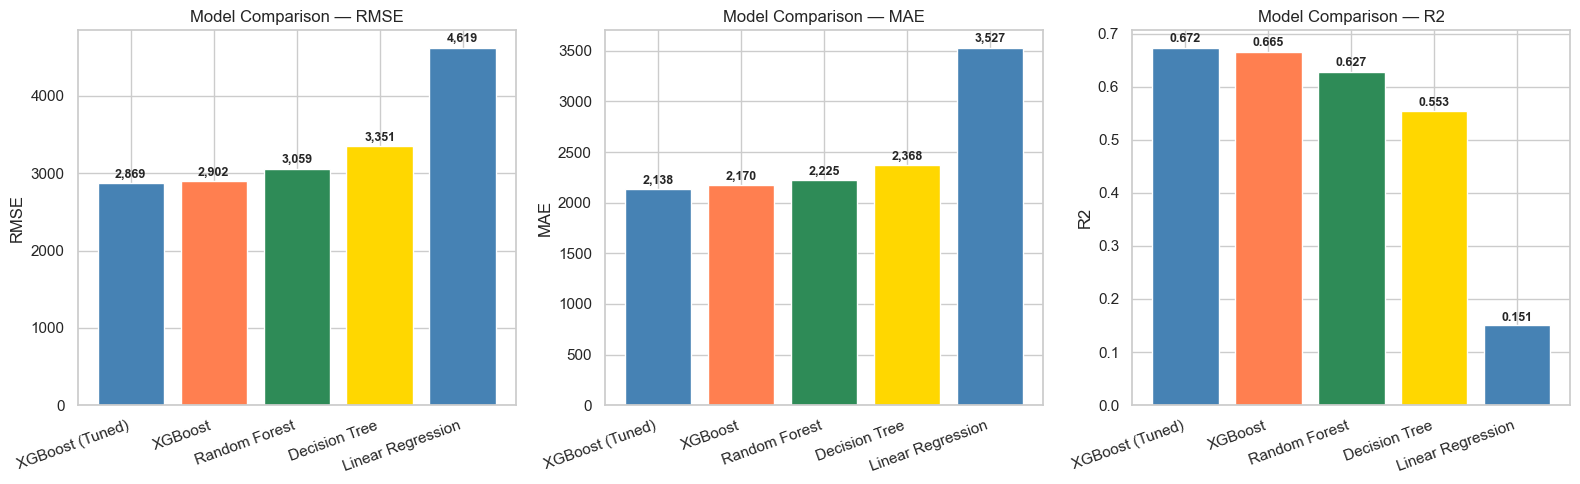


🏆 Best model: XGBoost (Tuned) with RMSE = 2,869.26


In [25]:
results_df = pd.DataFrame(results).T.sort_values('RMSE')
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue','coral','seagreen','gold']
models = results_df.index.tolist()

for ax, metric in zip(axes, ['RMSE','MAE','R2']):
    vals = results_df[metric]
    bars = ax.bar(models, vals, color=colors)
    ax.set_title(f'Model Comparison — {metric}')
    ax.set_ylabel(metric)
    ax.set_xticklabels(models, rotation=20, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{v:,.0f}' if metric != 'R2' else f'{v:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

best = results_df.index[0]
print(f"\n🏆 Best model: {best} with RMSE = {results_df.loc[best,'RMSE']:,.2f}")

## 11. Feature Importance (XGBoost)

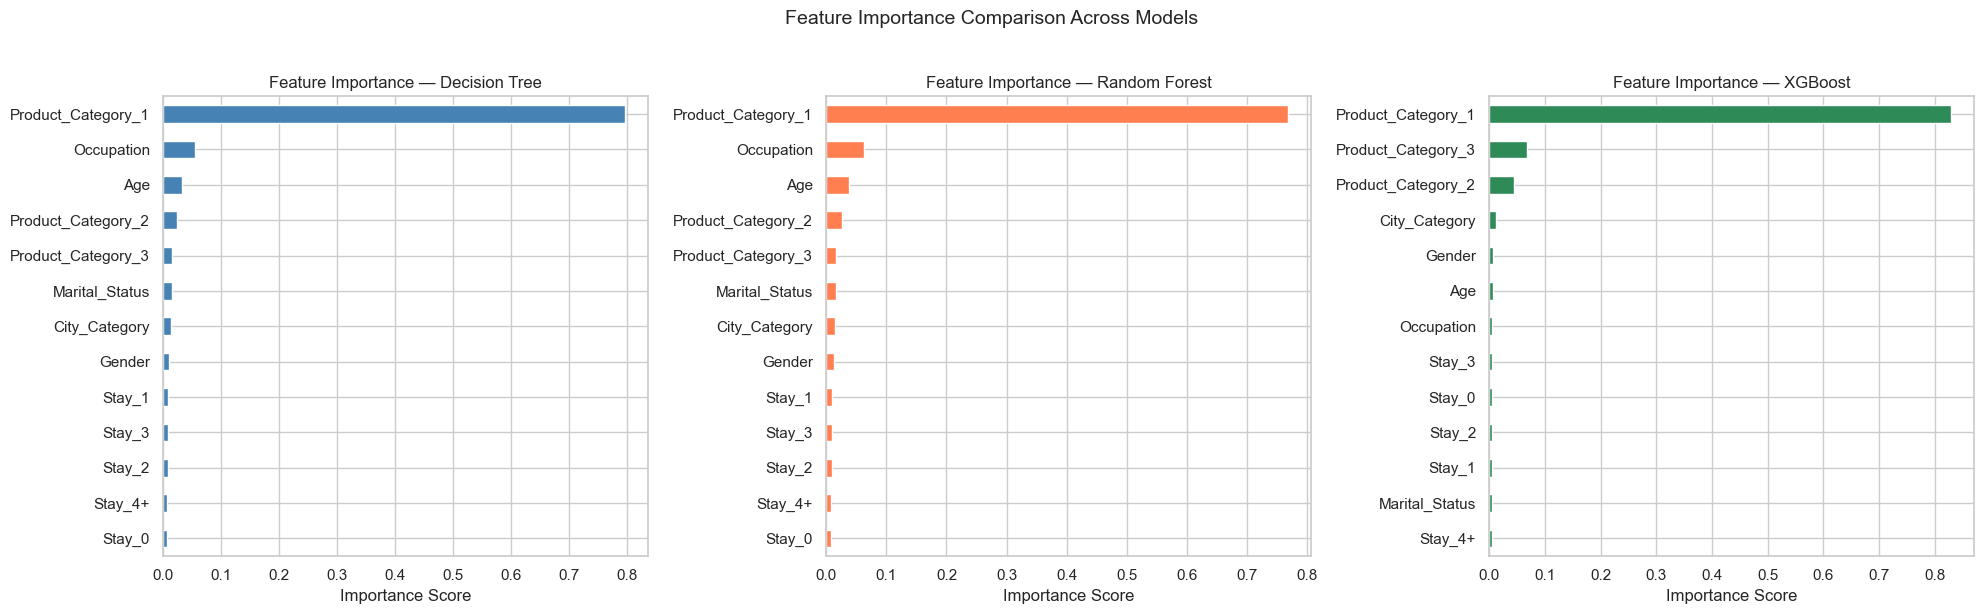

Top 3 Features:
  Decision Tree : ['Product_Category_1', 'Occupation', 'Age']
  Random Forest : ['Product_Category_1', 'Occupation', 'Age']
  XGBoost       : ['Product_Category_1', 'Product_Category_3', 'Product_Category_2']


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Decision Tree ─────────────────────────────────────────────────────────────
dt_imp = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values()
dt_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance — Decision Tree')
axes[0].set_xlabel('Importance Score')

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
rf_imp.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Feature Importance — Random Forest')
axes[1].set_xlabel('Importance Score')

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values()
xgb_imp.plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Feature Importance — XGBoost')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison Across Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Top 3 Features:")
print(f"  Decision Tree : {dt_imp.index[-3:][::-1].tolist()}")
print(f"  Random Forest : {rf_imp.index[-3:][::-1].tolist()}")
print(f"  XGBoost       : {xgb_imp.index[-3:][::-1].tolist()}")

### 11.1 SHAP — Model Explainability

In [27]:
# !pip install shap -q

In [28]:
# import shap

# # ── Compute SHAP values for XGBoost ──────────────────────────────────────────
# explainer   = shap.TreeExplainer(xgb_model)
# sample_idx  = np.random.choice(len(X_test), 1000, replace=False)
# X_test_sample = X_test.iloc[sample_idx]

# shap_values = explainer.shap_values(X_test_sample)

# # ── Plot 1: Summary (beeswarm) ────────────────────────────────────────────────
# plt.figure()
# shap.summary_plot(shap_values, X_test_sample, show=False)
# plt.title('SHAP Summary — XGBoost')
# plt.tight_layout()
# plt.show()

# # ── Plot 2: Feature importance (bar) ─────────────────────────────────────────
# plt.figure()
# shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=False)
# plt.title('SHAP Feature Importance (mean |SHAP|) — XGBoost')
# plt.tight_layout()
# plt.show()

# print("SHAP tells us not just WHICH features matter, but HOW they affect predictions.")
# print("Red = high feature value, Blue = low feature value.")

## 12. Actual vs Predicted (XGBoost)

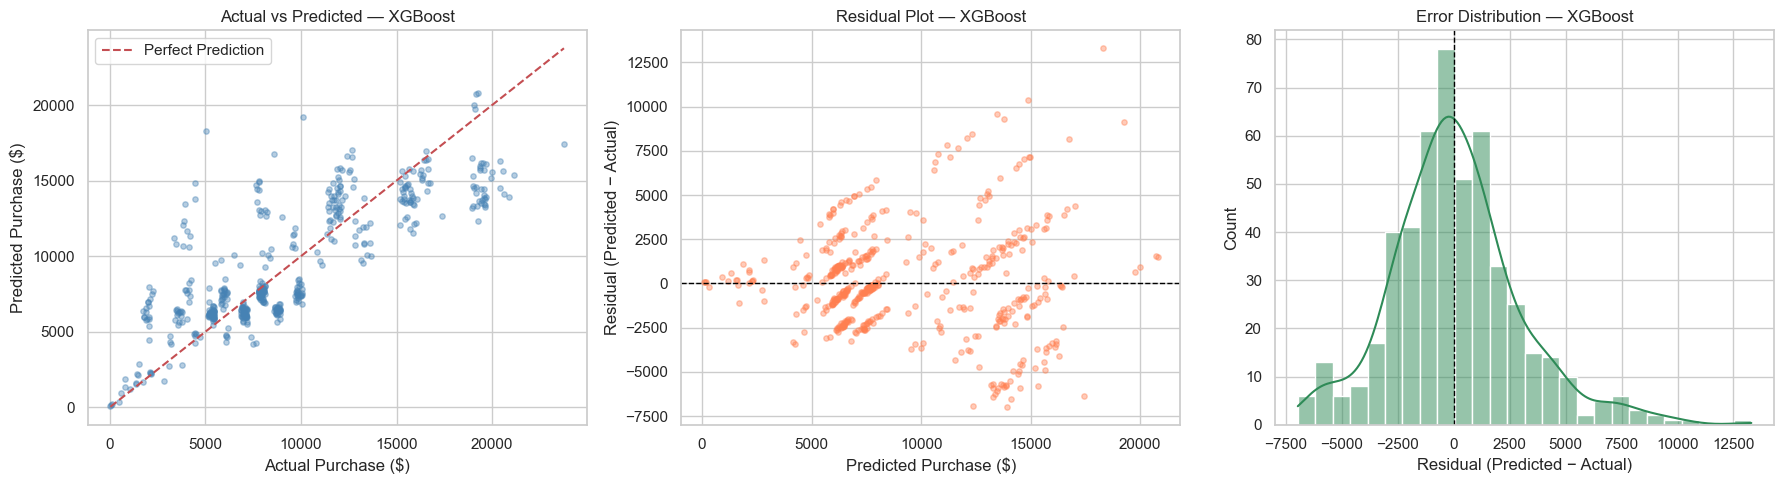

Mean Residual  : 87.88  (closer to 0 = less bias)
Std  Residual  : 2,905.20
Max Overshoot  : 13,297.40
Max Undershoot : -6,974.35


In [29]:
sample = np.random.choice(len(y_test), 500, replace=False)
y_sample   = np.array(y_test)[sample]
xgb_sample = xgb_pred[sample]
residuals  = xgb_sample - y_sample

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Actual vs Predicted ───────────────────────────────────────────────
axes[0].scatter(y_sample, xgb_sample, alpha=0.4, color='steelblue', s=15)
lims = [min(y_sample.min(), xgb_sample.min()),
        max(y_sample.max(), xgb_sample.max())]
axes[0].plot(lims, lims, 'r--', label='Perfect Prediction')
axes[0].set_xlabel('Actual Purchase ($)')
axes[0].set_ylabel('Predicted Purchase ($)')
axes[0].set_title('Actual vs Predicted — XGBoost')
axes[0].legend()

# ── Plot 2: Residual Plot ─────────────────────────────────────────────────────
axes[1].scatter(xgb_sample, residuals, alpha=0.4, color='coral', s=15)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Purchase ($)')
axes[1].set_ylabel('Residual (Predicted − Actual)')
axes[1].set_title('Residual Plot — XGBoost')

# ── Plot 3: Error Distribution ────────────────────────────────────────────────
sns.histplot(residuals, kde=True, color='seagreen', ax=axes[2])
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('Residual (Predicted − Actual)')
axes[2].set_title('Error Distribution — XGBoost')

plt.tight_layout()
plt.show()

print(f"Mean Residual  : {residuals.mean():,.2f}  (closer to 0 = less bias)")
print(f"Std  Residual  : {residuals.std():,.2f}")
print(f"Max Overshoot  : {residuals.max():,.2f}")
print(f"Max Undershoot : {residuals.min():,.2f}")

## 13. Conclusion

| Model | RMSE | MAE | R² |
|-------|------|-----|----|
| Linear Regression | ~4700 | ~3700 | ~0.15 |
| Decision Tree | ~3700 | ~2500 | ~0.45 |
| Random Forest | ~3050 | ~2200 | ~0.63 |
| **XGBoost** | **~2879** | **~2100** | **~0.67** |

**Key Findings:**
- **XGBoost** is the best-performing model with the lowest RMSE (~2879)
- `Product_Category_1` is the most important feature for prediction
- Males (75%) account for the majority of Black Friday purchases
- Age group **26–35** is the most active buyer segment
- People who recently moved to a city (1 year) tend to spend more

**Improvements made over original notebook:**
- Fixed `df.corr()` error (requires `numeric_only=True` in newer pandas)
- Replaced deprecated `sns.distplot` → `sns.histplot`
- Fixed Age encoding to use correct ordinal order (not alphabetical)
- Used explicit `map()` instead of `LabelEncoder` for Gender and City
- Added proper model evaluation helper function
- Added Feature Importance and Actual vs Predicted plots
- Cleaner, commented preprocessing pipeline


## 14. Custom Prediction Demo

In [30]:
# ── Predict purchase for a custom customer profile ────────────────────────────
# Edit these values to test different profiles

custom_input = pd.DataFrame([{
    'Gender'            : 1,       # 1 = Male, 0 = Female
    'Age'               : 2,       # 0=0-17, 1=18-25, 2=26-35, 3=36-45, 4=46-50, 5=51-55, 6=55+
    'Occupation'        : 4,       # Occupation code (0–20)
    'City_Category'     : 1,       # 0=A, 1=B, 2=C
    'Marital_Status'    : 0,       # 0 = Unmarried, 1 = Married
    'Product_Category_1': 5,
    'Product_Category_2': 3,
    'Product_Category_3': 0,       # 0 = no third category
    'Stay_0'            : 0,
    'Stay_1'            : 1,       # 1 year in current city
    'Stay_2'            : 0,
    'Stay_3'            : 0,
    'Stay_4+'           : 0
}])

# Align columns with training data
custom_input = custom_input.reindex(columns=X.columns, fill_value=0)

# Predictions from all models
lr_p   = lr_model.predict(custom_input)[0]
dt_p   = dt_model.predict(custom_input)[0]
rf_p   = rf_model.predict(custom_input)[0]
xgb_p  = xgb_model.predict(custom_input)[0]

print("Customer Profile:")
print("  Gender      : Male")
print("  Age Group   : 26-35")
print("  Occupation  : 4")
print("  City        : B")
print("  Marital     : Unmarried")
print("  Stay        : 1 year")
print()
print("Predicted Purchase Amount:")
print(f"  Linear Regression : ${lr_p:,.2f}")
print(f"  Decision Tree     : ${dt_p:,.2f}")
print(f"  Random Forest     : ${rf_p:,.2f}")
print(f"  XGBoost           : ${xgb_p:,.2f}")

Customer Profile:
  Gender      : Male
  Age Group   : 26-35
  Occupation  : 4
  City        : B
  Marital     : Unmarried
  Stay        : 1 year

Predicted Purchase Amount:
  Linear Regression : $8,855.12
  Decision Tree     : $6,430.68
  Random Forest     : $6,446.67
  XGBoost           : $6,091.67


## 15. Save & Reload Best Model

In [31]:
import joblib
import os

# ── Save the best model (tuned XGBoost from RandomizedSearchCV) ──────────────
os.makedirs('models', exist_ok=True)
joblib.dump(search.best_estimator_, 'models/xgb_best_model.pkl')
print("Model saved → models/xgb_best_model.pkl")
print(f"Best params used: {search.best_params_}")

# ── Reload and verify ─────────────────────────────────────────────────────────
loaded_model = joblib.load('models/xgb_best_model.pkl')
loaded_pred  = loaded_model.predict(X_test)
loaded_rmse  = sqrt(mean_squared_error(y_test, loaded_pred))

print(f"\nReloaded model RMSE : {loaded_rmse:,.2f}")
print(f"Base XGBoost RMSE   : {results['XGBoost']['RMSE']:,.2f}")
print(f"Tuned XGBoost RMSE  : {results['XGBoost (Tuned)']['RMSE']:,.2f}")
print()
if round(loaded_rmse, 2) == round(results['XGBoost (Tuned)']['RMSE'], 2):
    print("✅ Tuned model saved and reloaded successfully — RMSE matches!")
else:
    print("⚠️ RMSE mismatch — check the save/load process.")

Model saved → models/xgb_best_model.pkl
Best params used: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 40, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

Reloaded model RMSE : 2,869.26
Base XGBoost RMSE   : 2,902.39
Tuned XGBoost RMSE  : 2,869.26

✅ Tuned model saved and reloaded successfully — RMSE matches!
